# Scaling Up CPU Compute as Your Data Size Scales Up

When data is of an approachable size, many researchers start analysis on their laptops in a familiar computing environment. Let's simulate what that might look like with some synthetic single-band imagery.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%%time
n_images = int(1e3)
height = 64
width = 64

images = np.random.random((n_images, height, width)).astype(np.float32)

images.shape

CPU times: user 47.3 ms, sys: 15 ms, total: 62.3 ms
Wall time: 98 ms


(1000, 64, 64)

We can imagine that these are images related to a range of research topics: microscopy imagery of cellular structures, remote sensing data of the Martian polar ice caps, or seismic waveforms generated as radar waves are reflected through subsurface layers. In Python (and indeed in most programming languages used for scientific computing like R or Julia), these images are ultimately represented as arrays of numbers.

We can compute the average image:

In [3]:
%timeit images.mean(axis=0)

798 μs ± 6.34 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Now imagine that we have 1000 times the data. How long would this workflow take?

In [4]:
%%time
n_images = int(1e6)
height = 64
width = 64

images = np.random.random((n_images, height, width)).astype(np.float32)

images.shape

CPU times: user 32 s, sys: 14.7 s, total: 46.7 s
Wall time: 47 s


(1000000, 64, 64)

In [5]:
%timeit images.mean(axis=0)

1e+03 ms ± 25.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


When we contrast how long it takes for the data to "load" (or in this case be created), and for us to calculate the mean (an $\mathcal{O}(N)$ operation) in the smaller data case of 1000 images vs. the larger data case of 1000000 images, this is what we find.

How many times longer is loading for the larger data?

In [8]:
47/0.098

479.59183673469386

How many times longer is calculating the mean?

In [9]:
1/0.000798

1253.1328320802006

Taking the mean is a linear operation, so you can see that it takes about 1000x longer. If you wanted to run something more complex than calculating a mean, even a moderate increase in dataset size could turn into an analysis that takes days or becomes completely impractical on a single machine. As an example, matrix operations on the scale of $\mathcal{O}(N^2)$ like calculating certain machine learning kernels would take one million times longer at this larger data size. Calculations on the order of $\mathcal{O}(N^3)$ take one billion times longer.

To address this, we can use distributed computing tools, which extend familiar array- and dataframe-style workflows to datasets that may not fit in memory. When you run an operation, these tools can schedule these computations across multiple cores (or even multiple machines), executes them in parallel where possible, and then combines the results at the end. From the user’s perspective, the code often looks very similar to numpy or pandas, but the execution model is designed for scalability rather than single-machine performance.

---

<br>

# An Introduction to Dask for Parallel CPU Computing

Dask is a Python library designed to facilitate parallel computing and distributed data processing. It is particularly useful for handling computations that exceed the available memory of a single machine and for parallelizing tasks across multiple cores on distributed computing clusters (though it will work on your laptop compute too!). The primary goal of Dask is to provide a user-friendly and Pythonic interface for developers to scale their data analysis and processing workflows.

Dask consists of two main components:
1. **"Big Data" Collections:** Dask provides collections that extend common Python data structures, such as arrays, dataframes, and lists, to handle larger-than-memory or distributed datasets. These collections are designed to mimic the interfaces of popular libraries like NumPy and Pandas, making it easier for developers to transition from single-machine to distributed computing environments.
2. **Dynamic Task Scheduling:** Dask provides scheduling that manages the distribution and execution of tasks across the available computing resources. It ensures that computations are carried out efficiently in a parallelized manner.

![Dask Distributed System](https://docs.dask.org/en/stable/_images/dask-overview.svg)
High level collections are used to generate task graphs which can be executed by schedulers on a single machine or a cluster.

Some reasons why you should consider using Dask for your large data:

- **Scalable Parallel Computing:** Dask enables the parallelization of computations across multiple cores and distributed clusters, allowing users to efficiently handle data processing tasks that exceed the memory capacity of a single machine.
- **Lazy Evaluation:** Dask adopts a lazy evaluation approach, deferring the execution of operations until explicitly requested. This optimizes the scheduling and execution of computations, enhancing overall efficiency.
- **Flexibility Across Data Structures:** Dask provides "Big Data" collections that extend common Python data structures (e.g., arrays, dataframes, bags) to handle larger-than-memory or distributed datasets. This flexibility allows users to seamlessly transition between single-machine and distributed computing environments.
- **Integration with Distributed Computing:** Dask seamlessly integrates with a task scheduler, facilitating the scaling of computations from a single machine to distributed computing clusters. This adaptability makes Dask a versatile tool for handling diverse big data processing scenarios.

In essence, Dask offers a versatile and user-friendly framework for scalable, parallel, and distributed computing in Python, making it well-suited for a wide range of data analysis and processing tasks.

---

<br>

## Dask Arrays

Today, we'll be focusing on processing image data, i.e. array data, with `dask`, but it can also be used with most any familiar python data variables, like dataframes (or `pandas`-like variables) for example.

A `dask` array is very similar to a `numpy` or `xarray` array. However, a `dask` array is only symbolic, and doesn't initially hold any data. It is structured to represent the shape, chunks, and computations needed to generate the data. Dask remains efficient by delaying computations until the full computation thread is built up and the data is requested. This mode of operation is called “lazy evaluation” and this mode allows users to build up a symbolic thread of calculations before turning them over the scheduler for execution.

`dask` arrays arrange many python arrays into a grid. The underlying arrays are stored either locally, distributed across machines, or on a remote machine like the cloud.

Let's compare some `numpy` arrays to `dask` arrays to illustrate further how Dask operates. We'll begin by creating a `numpy` array of ones.

In [10]:
shape = (1000, 4000)
ones_np = np.ones(shape)
ones_np

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1000, 4000))

Let's look at the size of this array in memory:

In [11]:
print(f'Size in MB: {ones_np.nbytes / (1024 * 1024)}')

Size in MB: 30.517578125


Now, we'll create the same array in dask.

In [12]:
import dask.array as da
ones = da.ones(shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 4000), chunktype=numpy.ndarray>

Notice how this array comes with a `dask` visualization of our array and includes the word "chunks." Chunks are the way that `dask` splits the array into sub-arrays. We did not specify how we wanted to chunk the array, so `dask` just used one chunk for the whole array. At this point, the `dask` array is very similar to the `numpy` array and isn't structured to take advantage of dask functionality.

## Specifying Chunks

To leverage the full power of `dask`, we'll split our array into specified chunks. The [Dask documentation](https://dask.pydata.org/en/latest/array-chunks.html) provides several ways to specify chunks. In this demonstration, we'll use a block shape.

In [13]:
chunk_shape = (1000, 1000)
ones = da.ones(shape, chunks=chunk_shape)
ones

dask.array<ones_like, shape=(1000, 4000), dtype=float64, chunksize=(1000, 1000), chunktype=numpy.ndarray>

At this point, all we have is a symbolic represetnation of the array, including its shape, data type, and chunk size. This is an example of lazy evalution; unlike `numpy`, `dask` has not generated data yet.

In order to generate data, we need to send the data collection to the scheduler, which we can do by calling the `compute` function.

In [14]:
ones.compute()

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(1000, 4000))

Dask has a nifty `visualize` function that illustrates the symbolic operations that ran when we called `compute`.

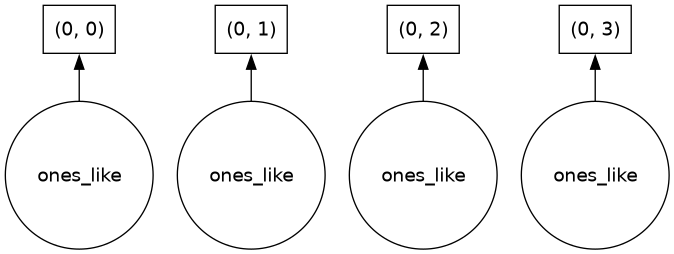

In [15]:
ones.visualize()

We can see that we stored four "ones-like" arrays, one in each chunk. To generate the data, the `dask` scheduler calls `np.ones` four times and then concatenates all of them together into one array.

Rather than immediately loading a `dask` array (which will store all of the data in RAM), we usually would like to do some kind of analysis on the data and don't necessarily want to store the full raw data in memory. Let's see how `dask` handles a more complex computation that reduces the data.

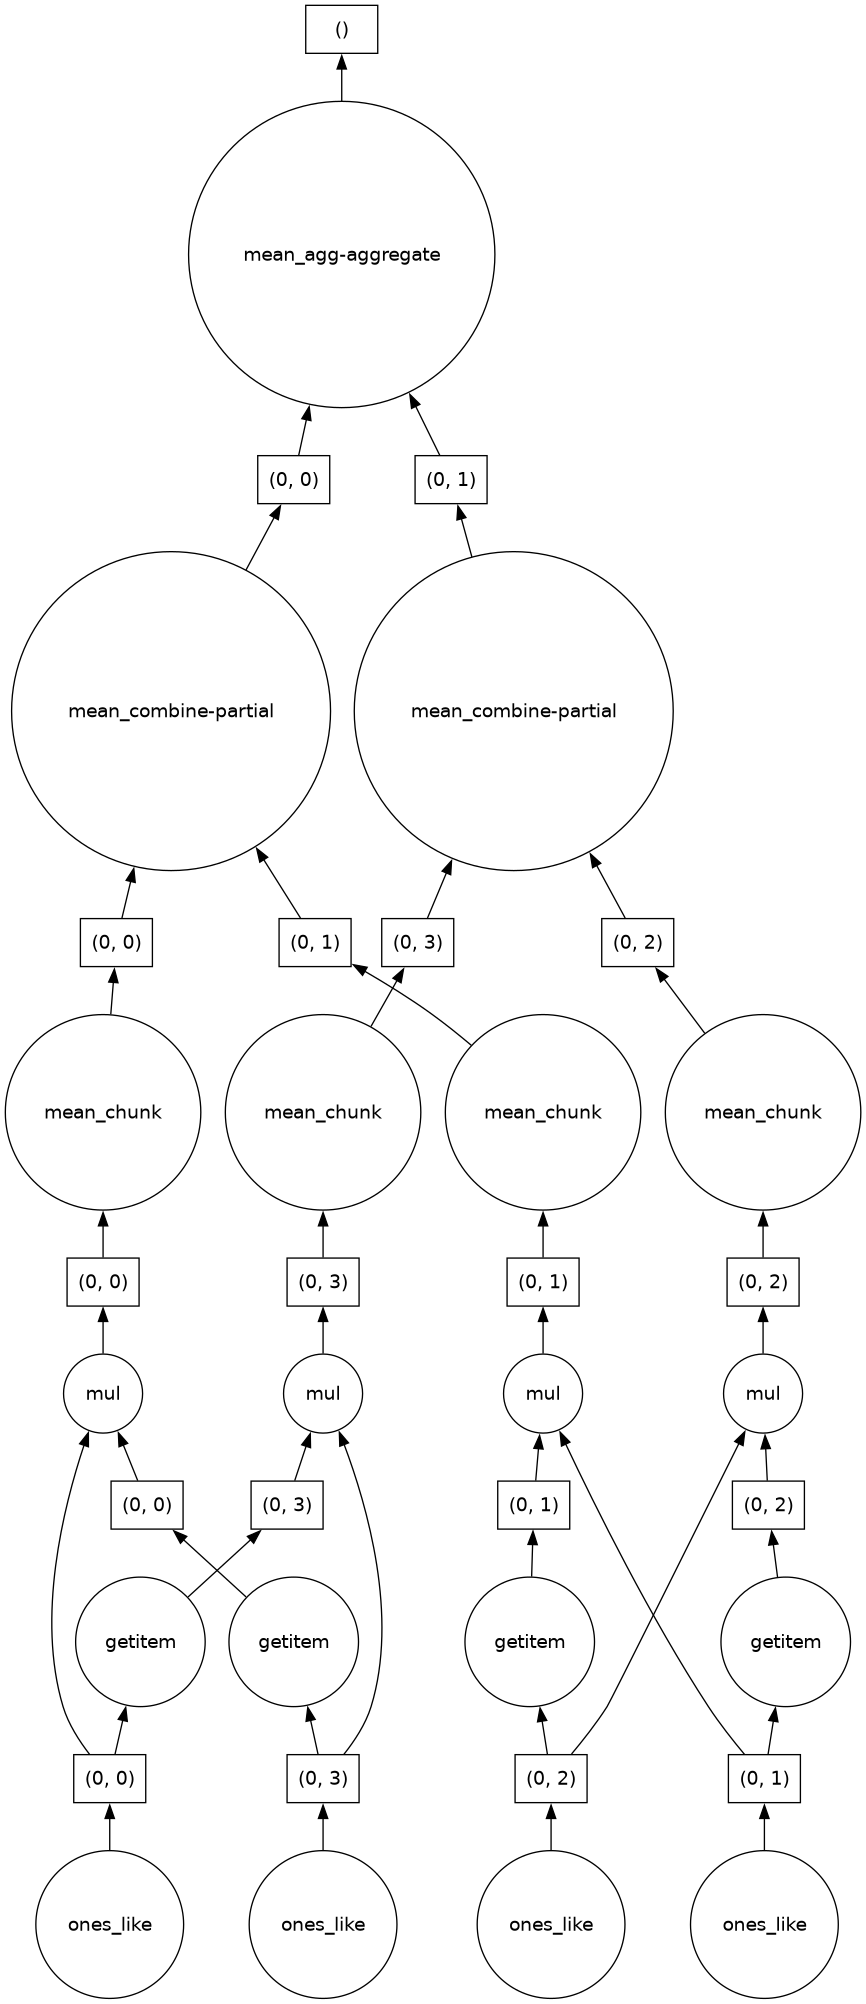

In [16]:
complex_calculation = (ones * ones[::-1, ::-1]).mean()
complex_calculation.visualize()

## Explicitly Distributing to Multiple CPU Cores in Dask

Up to this point in the tutorial we've been allowing Dask to use default scheduling behavior, and we don't know have much visibility into how Dask is distributing tasks across multiple cores. We can specify parallel execution more explicitly using Dask's distributed scheduler. The `dask` scheduler can be used on an HPC cluster or even on your local laptop.

In [17]:
from dask.distributed import Client

In [18]:
client = Client(n_workers=4, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 187.50 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33819,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46123,Total threads: 1
Dashboard: http://127.0.0.1:37310/status,Memory: 46.88 GiB
Nanny: tcp://127.0.0.1:40675,


Rather than using default scheduling like above, we have defined our scheduler to explicitly create 4 worker processes, which are each capable of executing tasks independently coordinated by the scheduler.

Let's run this computation explicitly comparing the time difference between sequential tasking (one worker) and parallel tasking across 4 workers.

In [19]:
client.close()
client = Client(n_workers=1, threads_per_worker=1)

In [20]:
%timeit complex_calculation.compute()

78.5 ms ± 2.47 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [21]:
client.close()
client = Client(n_workers=4, threads_per_worker=1)

In [22]:
%timeit complex_calculation.compute()

58.4 ms ± 5.73 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


Nothing has changed about the array definition, the computation, or the logistic sequence, but how the computation is scheduled is now inherently different. If tasks were completed sequentially before on one core, now four workers execute the tasks in parallel. So why isn't this four times slower? That's because there is still overhead in distributing tasks to each of the workers. This becomes even clearer if we use 8 workers for this relatively linear task. The cost of distributing is higher than the savings of parallelization here.

In [23]:
client.close()
client = Client(n_workers=8, threads_per_worker=1)

In [24]:
%timeit complex_calculation.compute()

The slowest run took 5.00 times longer than the fastest. This could mean that an intermediate result is being cached.
190 ms ± 134 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


This ran more than 3 times longer than running this analysis sequentially! This is why chunking matters. Chunking directly effects how many tasks exist and how efficiently CPUs can be used. Too few chunks compared to available cores means not enough workers. Too many tiny chunks and the overhead of distributing starts to dominate. We want to aim for a balance between chunk count, overhead, and the number of available cores to achieve efficient scaling.

## A Real World Usecase: Filtering with `scipy`

Instead of the synthetic `numpy` images that we loaded above, we'll now create the same synthetic dataset with a size of `(1000, 64, 64)` in Dask. By moving this into Dask, as opposed to `numpy`, this is lazily loaded and doesn't flood out our memory. It also allows us to define chunks of 1000 images each which can be processed in parallel to each other. 

In [25]:
client.close()
client = Client(n_workers=16, threads_per_worker=1)

In [26]:
x = da.random.random(
    (100000, height, width),
    chunks=(1000, height, width)
).astype("float32")

Now let's use a Gaussian filter from the `scipy` package to smooth our image. This is a common filter when preparing data for machine learning and AI usecases, and by using it with our Dask enabled array, we can now smooth our large array in parallel chunks.

In [27]:
from scipy.ndimage import gaussian_filter

In [28]:
def smooth(block):
    return gaussian_filter(block, sigma=1)

We apply this "lazily" so the tasks are mapped out, but not computed yet. This means that Dask behaves as a wrapper of sorts to `scipy`: Dask decides where and when each `scipy` task runs, and the `scipy` computations are executed on each chunk independently in parallel. Instead of running a Gaussian filter on a massive dataset, now a Gaussian filter is run on 1000 smaller batched datasets in parallel.

In [29]:
smoothed = x.map_blocks(smooth)
smoothed

dask.array<smooth, shape=(100000, 64, 64), dtype=float32, chunksize=(1000, 64, 64), chunktype=numpy.ndarray>

Because we have only run the mapping, this ran pretty quickly, but to actually filter the images, we need to run the computation. 

In [30]:
result = smoothed.compute()

In [31]:
result.shape

(100000, 64, 64)

For the sake of time today, we'll leave it as an exercise to see how much faster this is than running this sequentially on the image chunks. Next, we'll move onto learning how to scale to multiple GPUs using `pytorch`.